In [13]:
# Download the Auto MPG dataset
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data

--2026-03-09 17:04:38--  https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘auto-mpg.data.1’

auto-mpg.data.1         [ <=>                ]  29.58K  --.-KB/s    in 0.05s   

2026-03-09 17:04:38 (627 KB/s) - ‘auto-mpg.data.1’ saved [30286]



Current folder: /content
Files here: ['.config', 'auto-mpg.data.1', 'auto-mpg.data (1).txt', 'auto-mpg.data (3).txt', 'auto-mpg.data', 'auto-mpg.data.txt', 'auto-mpg.data (4).txt', 'auto-mpg.data (2).txt', 'sample_data']

Loaded dataset shape: (398, 8)
Missing values per column:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


/tmp/ipykernel_778/3548546390.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(DATA_PATH, delim_whitespace=True, header=None)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


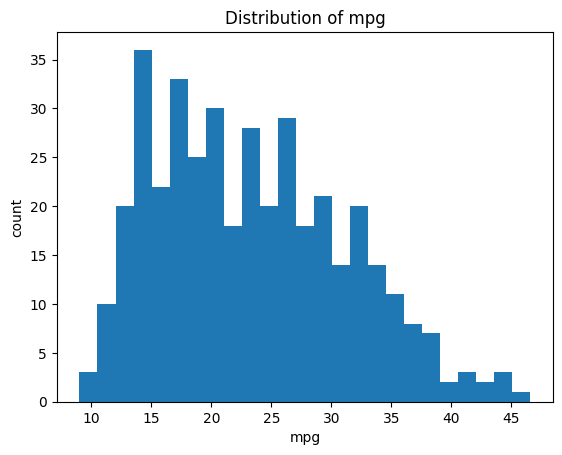

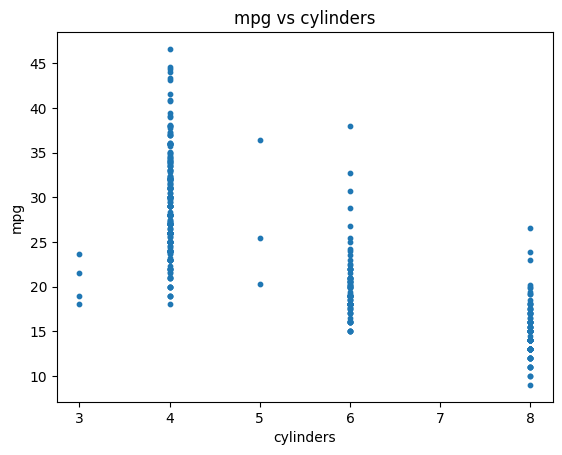

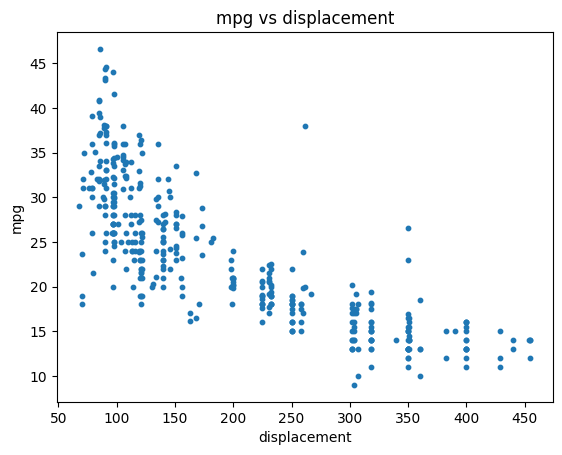

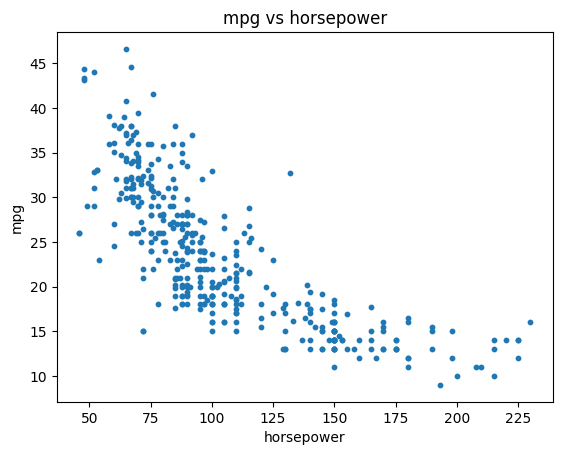

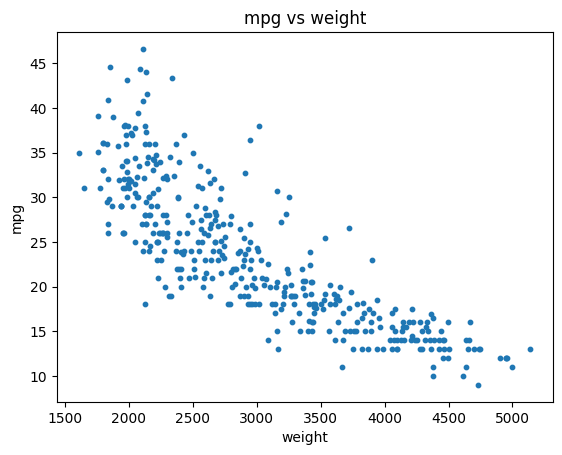

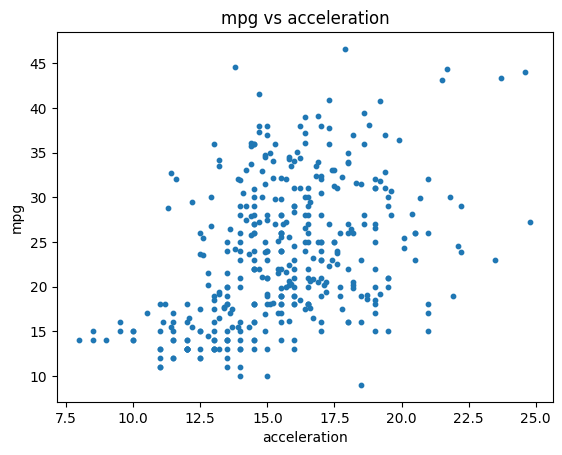

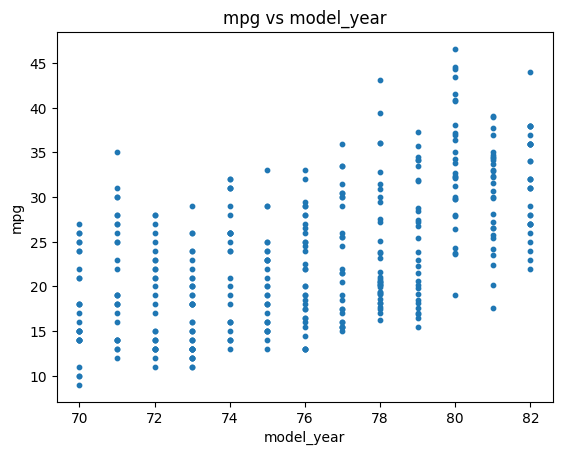

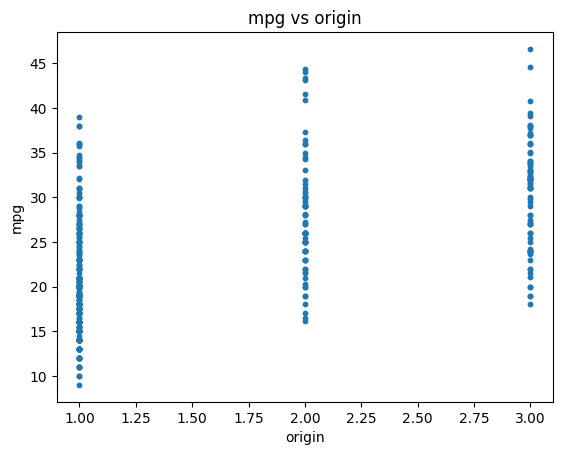

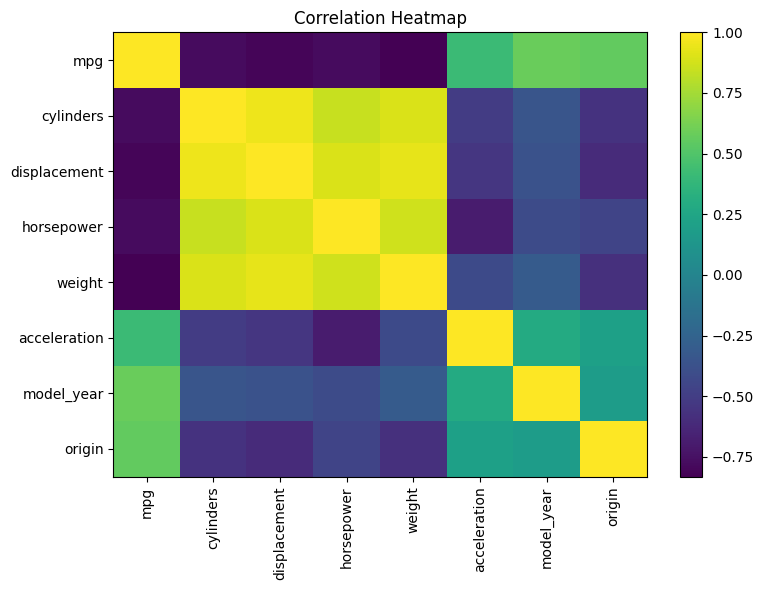


Split sizes:
Train: (238, 7) Val: (80, 7) Test: (80, 7)

--- VALIDATION RESULTS ---
Linear (val):  MSE=15.183  RMSE=3.896  MAE=2.905  R2=0.796


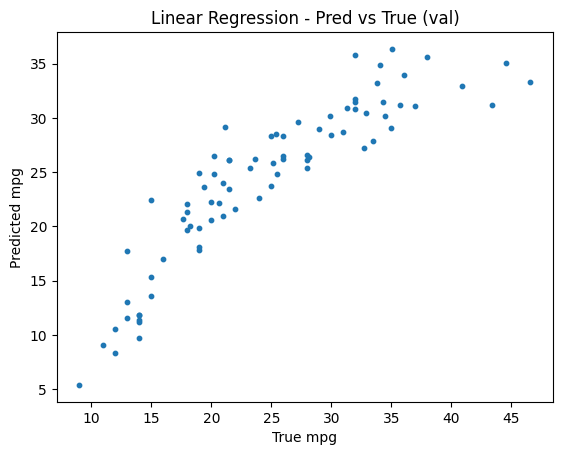


Best polynomial degree: 2


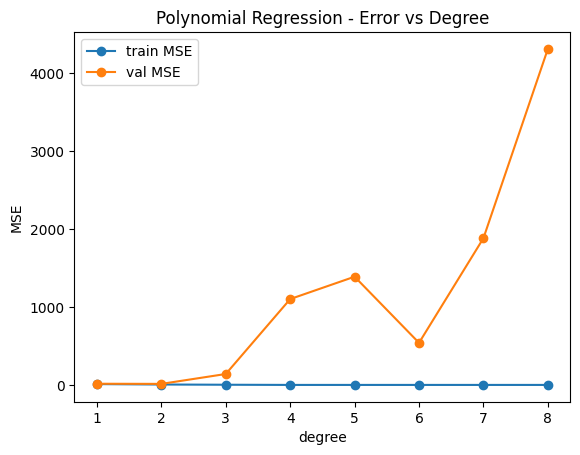

Best k: 5


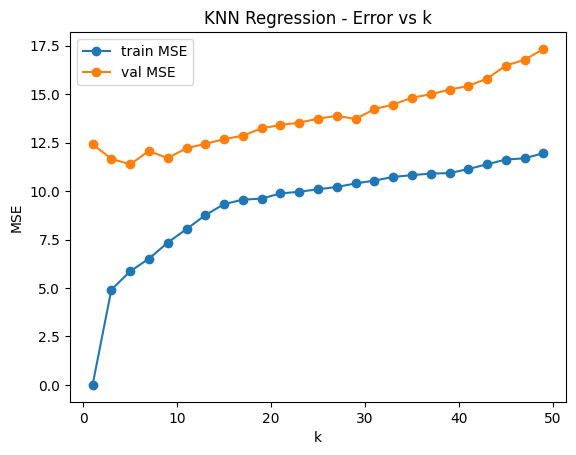


--- TEST RESULTS ---
Linear (test):  MSE=8.198  RMSE=2.863  MAE=2.256  R2=0.848
Poly deg=2 (test):  MSE=5.955  RMSE=2.440  MAE=1.851  R2=0.889
KNN k=5 (test):  MSE=5.401  RMSE=2.324  MAE=1.887  R2=0.900


5.400555

In [15]:
# =========================
# PART 1 - AUTO MPG (FINAL CLEAN + WORKING)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ========= 0) PATHS + CHECKS =========
DATA_PATH = "auto-mpg.data"   # ou "auto-mpg.data (1).txt" si c'est le nom exact

print("Current folder:", os.getcwd())
print("Files here:", os.listdir("."))

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"❌ I can't find the file: {DATA_PATH}")


# ========= 1) LOAD DATA =========
# auto-mpg.data.txt contains 8 numeric columns + car_name (text).
# We load only the first 8 numeric columns to avoid parsing issues with car_name.
df = pd.read_csv(DATA_PATH, sep='\s+', header=None)

df.columns = [
    "mpg","cylinders","displacement","horsepower",
    "weight","acceleration","model_year","origin","car_name"
]

df = df.drop(columns=["car_name"])

# handle missing values (sometimes horsepower has '?')
df = df.replace("?", np.nan)

# convert to numeric
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("\nLoaded dataset shape:", df.shape)
print("Missing values per column:\n", df.isna().sum())
display(df.head())


# ========= 2) EDA (PLOTS) =========
y = df["mpg"]

# Histogram of mpg
plt.figure()
plt.hist(y.dropna(), bins=25)
plt.title("Distribution of mpg")
plt.xlabel("mpg")
plt.ylabel("count")
plt.show()

numeric_cols = ["cylinders","displacement","horsepower","weight","acceleration","model_year","origin"]

# Scatter plots mpg vs each feature
for c in numeric_cols:
    plt.figure()
    plt.scatter(df[c], df["mpg"], s=10)
    plt.title(f"mpg vs {c}")
    plt.xlabel(c)
    plt.ylabel("mpg")
    plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
corr = df[["mpg"] + numeric_cols].corr(numeric_only=True)
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.tight_layout()
plt.show()


# ========= 3) SPLIT TRAIN / VAL / TEST =========
X = df.drop(columns=["mpg"])
y = df["mpg"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42
)  # 0.25 of 0.8 => 0.2, so 60/20/20 split

print("\nSplit sizes:")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


# ========= 4) PREPROCESS (impute + scale) =========
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols)
    ],
    remainder="drop"
)

def print_metrics(y_true, y_pred, name="Model"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}:  MSE={mse:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}")
    return mse


# ========= 5) LINEAR REGRESSION =========
lin = Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression())
])

lin.fit(X_train, y_train)
pred_val_lin = lin.predict(X_val)

print("\n--- VALIDATION RESULTS ---")
print_metrics(y_val, pred_val_lin, "Linear (val)")

plt.figure()
plt.scatter(y_val, pred_val_lin, s=10)
plt.title("Linear Regression - Pred vs True (val)")
plt.xlabel("True mpg")
plt.ylabel("Predicted mpg")
plt.show()


# ========= 6) POLYNOMIAL REGRESSION (degree search) =========
degrees = list(range(1, 9))
val_mse_poly = []
train_mse_poly = []

for d in degrees:
    poly = Pipeline([
        ("prep", preprocess),
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("model", LinearRegression())
    ])
    poly.fit(X_train, y_train)
    train_mse_poly.append(mean_squared_error(y_train, poly.predict(X_train)))
    val_mse_poly.append(mean_squared_error(y_val, poly.predict(X_val)))

best_deg = degrees[int(np.argmin(val_mse_poly))]
print("\nBest polynomial degree:", best_deg)

plt.figure()
plt.plot(degrees, train_mse_poly, marker="o", label="train MSE")
plt.plot(degrees, val_mse_poly, marker="o", label="val MSE")
plt.title("Polynomial Regression - Error vs Degree")
plt.xlabel("degree")
plt.ylabel("MSE")
plt.legend()
plt.show()

best_poly = Pipeline([
    ("prep", preprocess),
    ("poly", PolynomialFeatures(degree=best_deg, include_bias=False)),
    ("model", LinearRegression())
])
best_poly.fit(X_trainval, y_trainval)


# ========= 7) KNN REGRESSION (k search) =========
ks = list(range(1, 51, 2))
val_mse_knn = []
train_mse_knn = []

for k in ks:
    knn = Pipeline([
        ("prep", preprocess),
        ("model", KNeighborsRegressor(n_neighbors=k))
    ])
    knn.fit(X_train, y_train)
    train_mse_knn.append(mean_squared_error(y_train, knn.predict(X_train)))
    val_mse_knn.append(mean_squared_error(y_val, knn.predict(X_val)))

best_k = ks[int(np.argmin(val_mse_knn))]
print("Best k:", best_k)

plt.figure()
plt.plot(ks, train_mse_knn, marker="o", label="train MSE")
plt.plot(ks, val_mse_knn, marker="o", label="val MSE")
plt.title("KNN Regression - Error vs k")
plt.xlabel("k")
plt.ylabel("MSE")
plt.legend()
plt.show()

best_knn = Pipeline([
    ("prep", preprocess),
    ("model", KNeighborsRegressor(n_neighbors=best_k))
])
best_knn.fit(X_trainval, y_trainval)


# ========= 8) FINAL TEST RESULTS =========
print("\n--- TEST RESULTS ---")

# Linear refit on trainval
lin.fit(X_trainval, y_trainval)
print_metrics(y_test, lin.predict(X_test), "Linear (test)")

# Best poly
print_metrics(y_test, best_poly.predict(X_test), f"Poly deg={best_deg} (test)")

# Best knn
print_metrics(y_test, best_knn.predict(X_test), f"KNN k={best_k} (test)")

Batch GD - MSE val : 15.3225860216694
Batch GD - MSE test: 8.511334201685782


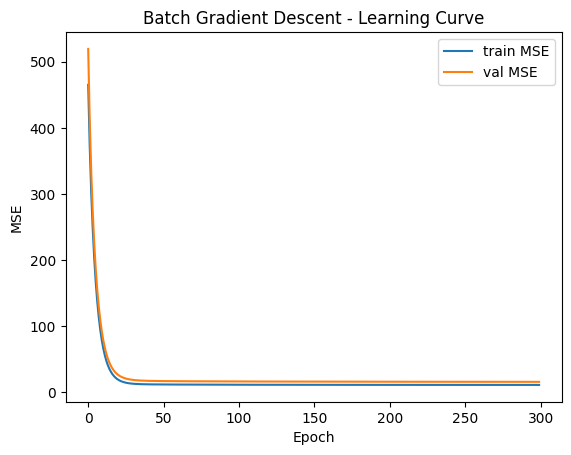

In [16]:
# =========================
# GRADIENT DESCENT (BATCH) - Linear Regression from scratch
# =========================

import numpy as np
import matplotlib.pyplot as plt

# On reprend les mêmes splits X_train, X_val, X_test et y_train, y_val, y_test
# et le même preprocess que dans ton code sklearn.

# 1) Transformer les features (impute + scale) en matrices numpy
Xtr = preprocess.fit_transform(X_train)      # fit sur train
Xva = preprocess.transform(X_val)            # transform sur val
Xte = preprocess.transform(X_test)           # transform sur test

ytr = y_train.to_numpy()
yva = y_val.to_numpy()
yte = y_test.to_numpy()

# 2) Ajouter la colonne de 1 pour le biais (intercept)
def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

Xtr_b = add_bias(Xtr)
Xva_b = add_bias(Xva)
Xte_b = add_bias(Xte)

# 3) MSE
def mse(y, yhat):
    return np.mean((y - yhat) ** 2)

# 4) Batch Gradient Descent
def batch_gradient_descent(X, y, Xv, yv, lr=0.05, epochs=300, seed=42):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    w = rng.normal(0, 0.1, size=d)  # init

    train_losses = []
    val_losses = []

    for _ in range(epochs):
        yhat = X @ w
        grad = (2/n) * (X.T @ (yhat - y))
        w = w - lr * grad

        train_losses.append(mse(y, X @ w))
        val_losses.append(mse(yv, Xv @ w))

    return w, train_losses, val_losses

w_batch, train_b, val_b = batch_gradient_descent(
    Xtr_b, ytr, Xva_b, yva, lr=0.05, epochs=300
)

print("Batch GD - MSE val :", mse(yva, Xva_b @ w_batch))
print("Batch GD - MSE test:", mse(yte, Xte_b @ w_batch))

plt.figure()
plt.plot(train_b, label="train MSE")
plt.plot(val_b, label="val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Batch Gradient Descent - Learning Curve")
plt.legend()
plt.show()

Mini-batch GD - MSE val : 15.124443504607353
Mini-batch GD - MSE test: 8.606712208938177


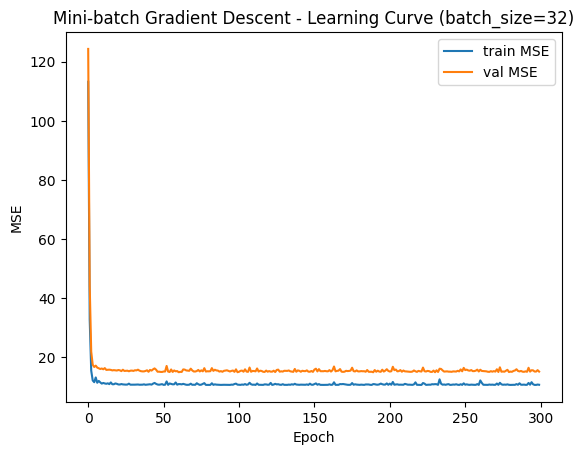

In [17]:
# =========================
# MINI-BATCH GRADIENT DESCENT
# =========================

def mini_batch_gradient_descent(X, y, Xv, yv, lr=0.05, epochs=300, batch_size=32, seed=42):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    w = rng.normal(0, 0.1, size=d)

    train_losses = []
    val_losses = []

    for _ in range(epochs):
        idx = rng.permutation(n)
        Xs = X[idx]
        ys = y[idx]

        for i in range(0, n, batch_size):
            Xb = Xs[i:i+batch_size]
            yb = ys[i:i+batch_size]
            nb = len(yb)

            yhat = Xb @ w
            grad = (2/nb) * (Xb.T @ (yhat - yb))
            w = w - lr * grad

        train_losses.append(mse(y, X @ w))
        val_losses.append(mse(yv, Xv @ w))

    return w, train_losses, val_losses

w_mini, train_m, val_m = mini_batch_gradient_descent(
    Xtr_b, ytr, Xva_b, yva, lr=0.05, epochs=300, batch_size=32
)

print("Mini-batch GD - MSE val :", mse(yva, Xva_b @ w_mini))
print("Mini-batch GD - MSE test:", mse(yte, Xte_b @ w_mini))

plt.figure()
plt.plot(train_m, label="train MSE")
plt.plot(val_m, label="val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Mini-batch Gradient Descent - Learning Curve (batch_size=32)")
plt.legend()
plt.show()